<a href="https://colab.research.google.com/github/dragonhumeante07/pruebas-de-codigos/blob/main/ejercicio_3_taller4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Taller 3 caso 4**
* **Introduccion**:
En este trabajo se abordará el caso 4 del taller 3 el cual consite en crear un sitema que permita:


1.   Buscar productos por código
2.   Buscar por nombre
3.   Analizar descripciones para encontrar productos relacionados

Para ello se deben aplicar tres tipos de búsqueda:
1. Búsqueda Binaria: para buscar productos por código
2. Búsqueda Secuencial: para buscar productos por nombre
3. Búsqueda de Texto: para buscar productos por descripciones relacionadas


#**Cargar desde el drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Busqueda binaria**


In [ ]:
import csv
class Producto:
    def __init__(self,codigo,nombre,descripcion,precio):
        self.codigo = codigo
        self.nombre = nombre
        self.descripcion = descripcion
        self.precio = precio
    def __str__(self):
        return f"Producto: {self.nombre} Código: {self.codigo} - Descripción: {self.descripcion}- precio: {self.precio}"

def busqueda_binaria(lista,valor,inicio,final):
    if inicio > final:
        return None
    media = (inicio + final)//2
    if lista[media].codigo == valor:
        return media
    elif lista[media].codigo > valor:
        return busqueda_binaria(lista,valor,inicio,media - 1)
    else :
        return busqueda_binaria(lista,valor,media + 1,final)
catalogo = []
ruta_permanente = '/content/drive/MyDrive/catalogo.txt'
with open(ruta_permanente, mode = 'r',encoding='utf-8') as archivo:
    lector = csv.reader(archivo)
    for lista in lector:
        if len(lista) == 4:
            codigo, nombre, descripcion, precio = lista
            producto = Producto(int(codigo), nombre, descripcion, int(precio))
            catalogo.append(producto)

for i in range(len(catalogo)):
    swapped = False  # Bandera para detectar si hubo intercambios en esta pasada

    for j in range(len(catalogo) - i - 1):
        if catalogo[j].codigo > catalogo[j + 1].codigo:
            # Intercambio de valores
            catalogo[j], catalogo[j + 1] = catalogo[j + 1], catalogo[j]
            swapped = True  # Hubo un cambio, la lista aún podría estar desordenada

    # Optimización: Si no hubo cambios, la lista ya está ordenada y salimos del bucle
    if not swapped:
        break

for producto in catalogo:
    print(producto)

buscado = int(input ("Ingrese el codigo del producto que desea buscar: "))
resultado = busqueda_binaria(catalogo, buscado,0,len(catalogo)-1)

if resultado is not None:
    print(catalogo[resultado])
else:
    print("No se encontró el producto.")


# **Tabla de tiempo(binaria)**


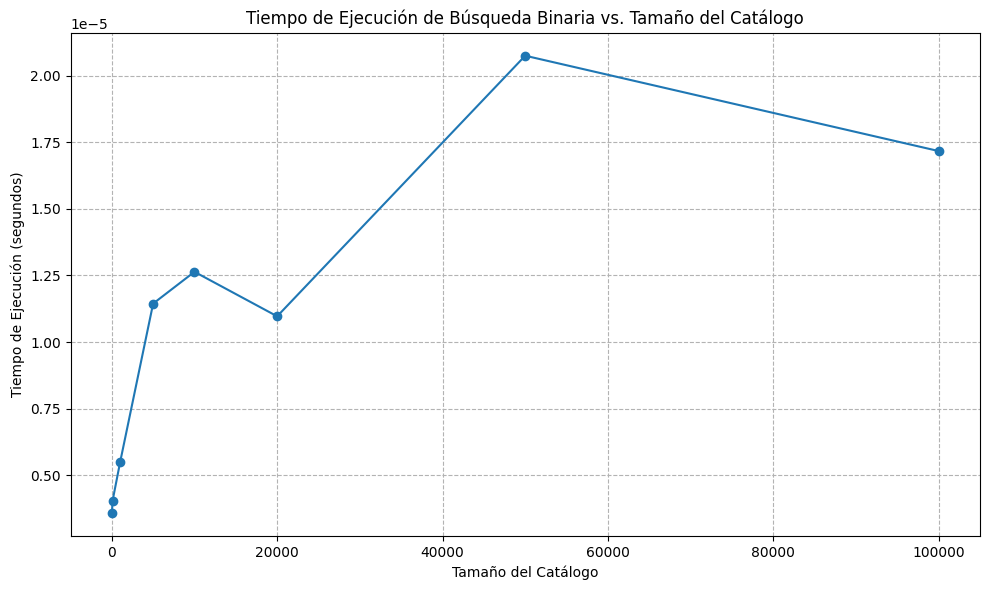

In [ ]:
import time
import matplotlib.pyplot as plt
import random


class Producto:
    def __init__(self,codigo,nombre,descripcion,precio):
        self.codigo = codigo
        self.nombre = nombre
        self.descripcion = descripcion
        self.precio = precio
    def __str__(self):
        return f"Producto: {self.nombre} Código: {self.codigo} - Descripción: {self.descripcion}- precio: {self.precio}"

def busqueda_binaria(lista,valor,inicio,final):
    if inicio > final:
        return None
    media = (inicio + final)//2
    if lista[media].codigo == valor:
        return media
    elif lista[media].codigo > valor:
        return busqueda_binaria(lista,valor,inicio,media - 1)
    else :
        return busqueda_binaria(lista,valor,media + 1,final)


def generate_sorted_products(size):
    products = []
    for i in range(size):
        # Ensure unique and sorted codes for binary search
        products.append(Producto(i, f"Product{i}", f"Desc{i}", random.randint(10, 1000)))
    return products

sizes = [10, 100, 1000, 5000, 10000, 20000, 50000, 100000]
times = []

for size in sizes:
    catalogo_test = generate_sorted_products(size)

    # Choose a value to search for. For worst-case or average, we can pick different values.
    # Let's search for an element that is likely to be found, or not found at the end.
    search_value = random.randint(0, size - 1) # Search for an existing code
    # search_value = size + 100 # For not found case

    start_time = time.time()
    busqueda_binaria(catalogo_test, search_value, 0, len(catalogo_test) - 1)
    end_time = time.time()
    times.append(end_time - start_time)

plt.figure(figsize=(10, 6))
plt.plot(sizes, times, marker='o', linestyle='-')
plt.xscale('linear') # Changed from log to linear
plt.yscale('linear') # Changed from log to linear
plt.title('Tiempo de Ejecución de Búsqueda Binaria vs. Tamaño del Catálogo')
plt.xlabel('Tamaño del Catálogo') # Updated label
plt.ylabel('Tiempo de Ejecución (segundos)') # Updated label
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()


#**Busqueda lineal**

In [ ]:
import csv
class Producto:
    def __init__(self,codigo,nombre,descripcion,precio):
        self.codigo = codigo
        self.nombre = nombre
        self.descripcion = descripcion
        self.precio = precio
    def __str__(self):
        return f"Producto: {self.nombre} Código: {self.codigo} - Descripción: {self.descripcion}- precio: {self.precio}"

def buscar_producto(lista,valor):
    for producto in lista:
        if producto.nombre.lower() == valor.lower():
            return producto
    return None

catalogo = []
ruta_permanente = '/content/drive/MyDrive/catalogo.txt'
with open(ruta_permanente, mode = 'r',encoding='utf-8') as archivo:
    lector = csv.reader(archivo)
    for lista in lector:
        if len(lista) == 4:
            codigo, nombre, descripcion, precio = lista
            producto = Producto(int(codigo), nombre, descripcion, int(precio))
            catalogo.append(producto)


buscado = input ("Ingrese el nombre del producto que desea buscar: ")
resultado = buscar_producto(catalogo,buscado)

if resultado is not None:
    print(resultado)
else:
    print("No se encontró el producto.")

Ingrese el nombre del producto que desea buscar: chaumpú
No se encontró el producto.


# grafico binario

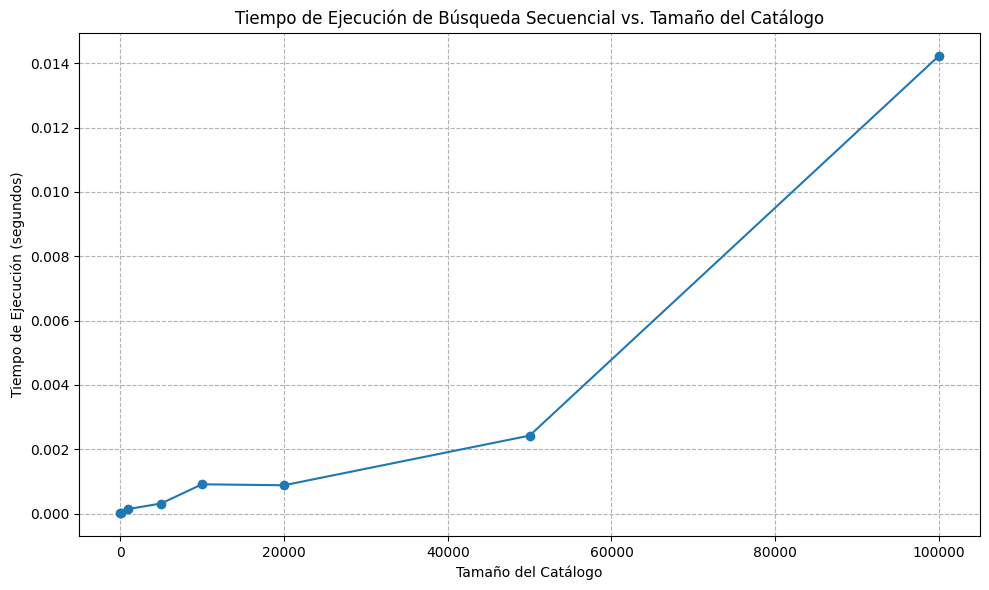

In [1]:
import time
import matplotlib.pyplot as plt
import random
import csv

class Producto:
    def __init__(self, codigo, nombre, descripcion, precio):
        self.codigo = codigo
        self.nombre = nombre
        self.descripcion = descripcion
        self.precio = precio

    def __str__(self):
        return f"Producto: {self.nombre} Código: {self.codigo} - Descripción: {self.descripcion}- precio: {self.precio}"

def buscar_producto(lista, valor):
    for producto in lista:
        if producto.nombre.lower() == valor.lower():
            return producto
    return None

def generate_products(size):
    products = []
    for i in range(size):
        products.append(Producto(i, f"Product{i}", f"Desc{i}", random.randint(10, 1000)))
    return products

sizes = [10, 100, 1000, 5000, 10000, 20000, 50000, 100000]
times = []

for size in sizes:
    catalogo_test = generate_products(size)

    # Choose a value to search for. For worst-case, we can pick a non-existent value or the last element.
    search_value = f"Product{random.randint(0, size - 1)}" # Search for an existing name
    # search_value = "NonExistentProduct" # For worst case (not found)

    start_time = time.time()
    buscar_producto(catalogo_test, search_value)
    end_time = time.time()
    times.append(end_time - start_time)

plt.figure(figsize=(10, 6))
plt.plot(sizes, times, marker='o', linestyle='-')
plt.xscale('linear')
plt.yscale('linear')
plt.title('Tiempo de Ejecución de Búsqueda Secuencial vs. Tamaño del Catálogo')
plt.xlabel('Tamaño del Catálogo')
plt.ylabel('Tiempo de Ejecución (segundos)')
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()

#**Busqueda texto**

In [ ]:
import csv
class Producto:
    def __init__(self,codigo,nombre,descripcion,precio):
        self.codigo = codigo
        self.nombre = nombre
        self.descripcion = descripcion
        self.precio = precio
    def __str__(self):
        return f"Producto: {self.nombre} Código: {self.codigo} - Descripción: {self.descripcion}- precio: {self.precio}"

def busqueda_texto(lista_productos, patron):
    productos_encontrados = []
    for producto in lista_productos:
        if patron.lower() in producto.descripcion.lower():
            productos_encontrados.append(producto)
    return productos_encontrados
catalogo = []
ruta_permanente = '/content/drive/MyDrive/catalogo.txt'
with open(ruta_permanente, mode = 'r',encoding='utf-8') as archivo:
    lector = csv.reader(archivo)
    for lista in lector:
        if len(lista) == 4:
            codigo, nombre, descripcion, precio = lista
            producto = Producto(int(codigo), nombre, descripcion, int(precio))
            catalogo.append(producto)

texto = catalogo
buscado = input ("Ingrese la descripcion del producto: ")
resultado = busqueda_texto(texto,buscado)
if resultado is not None:
    for producto in resultado:
        print(producto)
else:
    print("No se encontró el producto.")

Ingrese la descripcion del producto: Hogar
Producto: Lámpara LED Código: 1 - Descripción: Hogar- precio: 2800
Producto: Cafetera de prensa francesa Código: 4 - Descripción: Hogar- precio: 10000


#grafico de texto

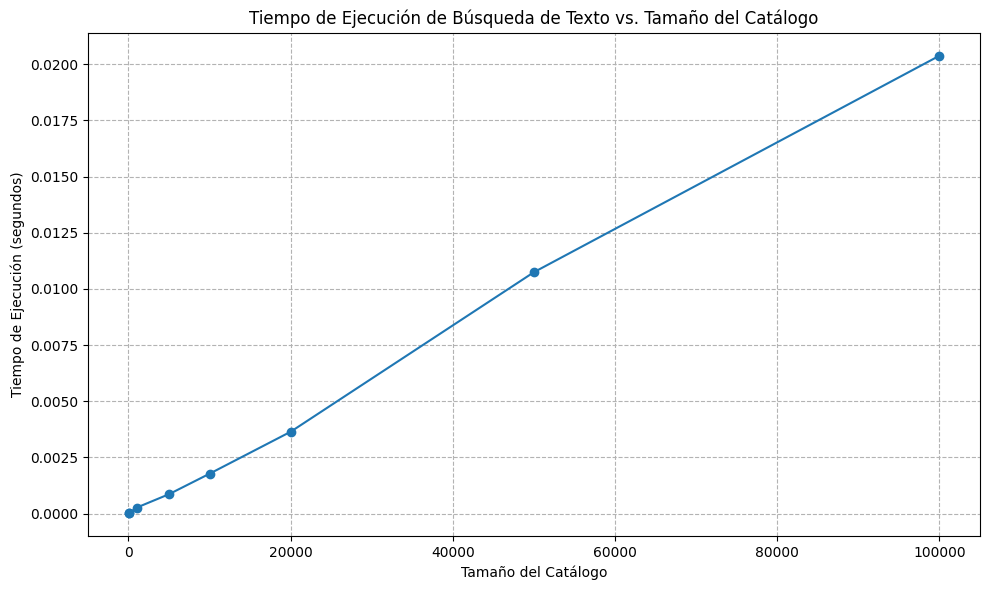

In [2]:
import time
import matplotlib.pyplot as plt
import random
import csv

class Producto:
    def __init__(self, codigo, nombre, descripcion, precio):
        self.codigo = codigo
        self.nombre = nombre
        self.descripcion = descripcion
        self.precio = precio

    def __str__(self):
        return f"Producto: {self.nombre} Código: {self.codigo} - Descripción: {self.descripcion}- precio: {self.precio}"

def busqueda_texto(lista_productos, patron):
    productos_encontrados = []
    for producto in lista_productos:
        if patron.lower() in producto.descripcion.lower():
            productos_encontrados.append(producto)
    return productos_encontrados

def generate_products_for_text_search(size):
    products = []
    common_descriptions = ["Hogar", "Cocina", "Electrónica", "Deportes", "Moda", "Libros", "Juguetes", "Jardín"]
    for i in range(size):
        # para buscar productos deseados
        desc = random.choice(common_descriptions) if i % 10 != 0 else f"UniqueDesc{i}"
        products.append(Producto(i, f"Product{i}", desc, random.randint(10, 1000)))
    return products

sizes = [10, 100, 1000, 5000, 10000, 20000, 50000, 100000]
times = []

for size in sizes:
    catalogo_test = generate_products_for_text_search(size)
    search_pattern = "hogar"
    start_time = time.time()
    busqueda_texto(catalogo_test, search_pattern)
    end_time = time.time()
    times.append(end_time - start_time)

plt.figure(figsize=(10, 6))
plt.plot(sizes, times, marker='o', linestyle='-')
plt.xscale('linear')
plt.yscale('linear')
plt.title('Tiempo de Ejecución de Búsqueda de Texto vs. Tamaño del Catálogo')
plt.xlabel('Tamaño del Catálogo')
plt.ylabel('Tiempo de Ejecución (segundos)')
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()